In [1]:
import numpy as np

X_train = np.load("processed_data/X_train.npy")
y_train = np.load("processed_data/y_train.npy")

print(X_train.shape)
print(y_train.shape)

(17731, 30, 16)
(17731,)


In [2]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42
)

In [3]:
import torch
from torch.utils.data import Dataset, DataLoader

class RULDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [4]:
train_dataset = RULDataset(X_train, y_train)
val_dataset = RULDataset(X_val, y_val)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [5]:
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat = X_val.reshape(X_val.shape[0], -1)

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_flat, y_train)

preds = rf.predict(X_val_flat)

mae = mean_absolute_error(y_val, preds)
rmse = np.sqrt(mean_squared_error(y_val, preds))
r2 = r2_score(y_val, preds)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 13.656239075274883
RMSE: 17.73199961103676
R2: 0.8185642022552516


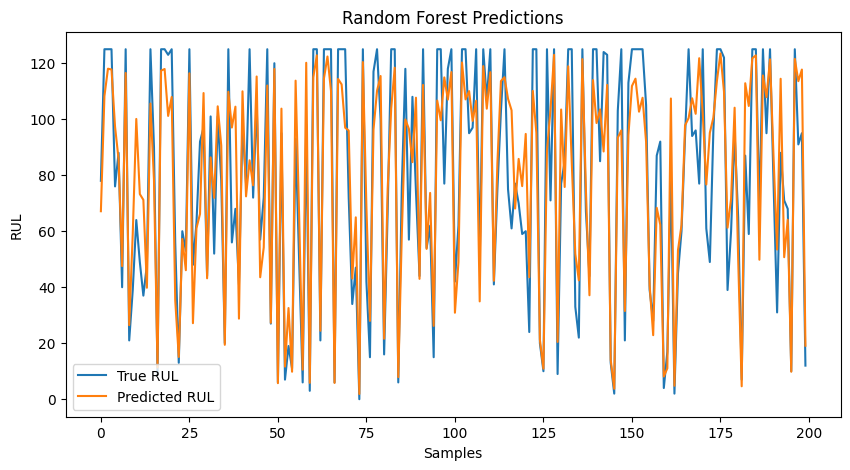

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_val[:200], label="True RUL")
plt.plot(preds[:200], label="Predicted RUL")

plt.xlabel("Samples")
plt.ylabel("RUL")
plt.title("Random Forest Predictions")

plt.legend()
plt.show()